# Multivariate Regression - Naive Approach

In this project, we display our naive solution to the problem of approximating a function $f: \R^n \to \R_m$ using a generalized regression model in any number of dimensions. Our optimized solution can be found on the notebook [02_optimized_solution.ipynb](./02_optimized_solution.ipynb)

## Setup
---

In [2]:
# Use this to download and install packages in the notebook if needed
# !pip install -q numpy sympy matplotlib scikit-learn tqdm

In [3]:
# Needed libraries
import sys
import numpy as np
import sympy as sp
import matplotlib as mpl
import itertools as it      # needed for combinations and permutations
import sklearn as skl

# Needed submodules
from matplotlib import pyplot as plt    # needed for plotting
from sympy.polys.monomials import itermonomials     # needed for generating monomials
from tqdm import tqdm    # needed for progress bars
from sklearn.decomposition import PCA   # needed for PCA
from sklearn.manifold import TSNE       # needed for t-SNE

# Check the versions
print("🐍 Python version:", sys.version)
print("📦 NumPy version:", np.__version__)
print("🔢 SymPy version:", sp.__version__)
print("📊 Matplotlib version:", mpl.__version__)
print("📈 scikit-learn version:", skl.__version__)

🐍 Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
📦 NumPy version: 2.3.3
🔢 SymPy version: 1.14.0
📊 Matplotlib version: 3.10.6
📈 scikit-learn version: 1.7.2


In [4]:
# Commonly used symbols
x, y, z = sp.symbols('x y z')

## Math Exploration

***  



Suppose we wish to approximate a given multivariate function $f:\mathbb{R}^n\to\mathbb{R}^m$ using a finite family of candidate functions called the “basis” functions $\Phi={\phi_0,\, \phi_1,\,\dots,\, \phi_k}$. A natural way to view this task is as a projection problem.

First, consider the collection

$$
V=\{\,f\mid f:\mathbb{R}^n\to\mathbb{R}^m\,\}.
$$

Because $V$ is closed under addition and scalar multiplication, it forms a vector space.

We can introduce the inner product

$$
\langle f,g\rangle 
= \int_{\Omega} f(\vec{x}) \cdot g(\vec{x})\,\mathrm{d}\vec{x},
$$

where “$\cdot$” is the standard $\langle \cdot \rangle_{\R^n} $ dot product in $\mathbb{R}^m$.

For the integral to be finite we must restrict the set of available functions to

$$
V_{\Omega}=\{\,f\in V\mid f_i\in L^2(\Omega)\text{ for }i=1,\dots,m\,\},
$$

meaning each component is square‑integrable over the bounded, measurable domain $\Omega\subset\mathbb{R}^n$. With this restriction $(V_{\Omega},\langle\cdot,\cdot\rangle)$ becomes a Hilbert space.

Since the dot product splits into components, the inner product expands as

$$
\langle f,g\rangle=
\int_{\Omega}\sum_{i=1}^m f_i(\vec{x})\,g_i(\vec{x})\,\mathrm{d}\vec{x}
=\sum_{i=1}^m \int_{\Omega} f_i(\vec{x})\,g_i(\vec{x})\,\mathrm{d}\vec{x}.
$$

Choosing a convenient rectangular domain $\Omega=[a_1,\, b_1]\times\cdots\times[a_n,\, b_n]$ gives a concrete formula:

$$
\langle \, f(\vec x) ,\, g(\vec x) \,\rangle
  = \sum_{i=1}^m \,
    \underbrace{\int_{a_1}^{b_1}\!\cdots\!\int_{a_n}^{b_n}}_{n \text{ times}} \;
    f_i(\underbrace{x_1,\dots,x_n}_{n \text{ times}} ) \,
    g_i(\underbrace{x_1,\dots,x_n}_{n \text{ times}}) \;
    \underbrace{\mathrm{d}x_n\cdots\mathrm{d}x_1}_{n \text{ times}}
$$


If instead of a continuous function, our target is a sample of points, we can replace the integral with a sum and hope it works 🙏.

$$\langle f, g\rangle
= \sum_{i=1}^m \sum_{\vec{p_i}}^m f_i(\vec{p_i})\,g_i(\vec{p_i})$$


By restructuring the commonly used orthogonal equation, we can create the system:
$$G A = X Y$$

where $G$ is the Gram matrix formed by

$$ G_{ij} = \langle \phi_i ,\, \phi_j \rangle $$

In explicit block form, this problem becomes:

$$
\underbrace{
  \begin{bmatrix}
    \langle \phi_0, \phi_0\rangle
    & \langle \phi_0, \phi_1\rangle
    & \cdots
    & \langle \phi_0, \phi_n\rangle \\[0.75em]
    \langle \phi_1, \phi_0\rangle
    & \langle \phi_1, \phi_1\rangle
    & \cdots
    & \langle \phi_1, \phi_n\rangle \\[0.75em]
    \vdots & \vdots & \ddots & \vdots \\[0.5em]
    \langle \phi_n, \phi_0\rangle
    & \langle \phi_n, \phi_1\rangle
    & \cdots
    & \langle \phi_n, \phi_n\rangle
  \end{bmatrix}
}_{G}
\;
\underbrace{
\begin{bmatrix}
  a_0 \\[0.5em] a_1 \\[0.5em] \vdots \\[0.5em] a_n
\end{bmatrix}
}_A

=

\underbrace{
\begin{bmatrix}
  \langle f, \phi_0\rangle \\[0.75em]
  \langle f, \phi_1\rangle \\[0.75em]
  \vdots \\[0.5em]
  \langle f, \phi_n\rangle
\end{bmatrix}.
}_{XY}

$$



A very natural way to build a basis is by using polynomials. To construct such a basis, we must have the terms

$$\phi_k = \hat{e}_d \prod x_i^{\alpha_i} $$

where $\hat{e}_d$ is a unit vector with value $1$ in the component of index $d$ and value $0$ elsewhere.

$\prod x_i^{\alpha_i} $ forms the cross terms of $x_i$ variables with sum of powers equal to $p$.

Thus, the polynomial can be formulated as

$$P_r(\vec x) = \sum_{j = 0}^{r} \sum_{d = 1}^{m} \sum_{i = 1}^{n} \hat{e}_d \prod_{\sum_i \alpha_i = r} x_i^{\alpha_i} $$

Note that we must either use tensor operations, creating a vector index $\vec k$, or we create a mapping
$$(d, \vec \alpha) \to k$$
to use with our regular matrix operations. Mathematically, they should be equivalent.

This basis has the advantage of being straightforward to integrate and manipulate, so we can compute the inner products for reasonably sized problems. However, it is not orthogonal, so the resulting Gram matrix may become ill-conditioned for high-degree bases.

## Toy Problem

Let's see how that works in practice with a small toy problem. We will be creating the multivariate polynomial basis using computer algebra:

In [5]:
# Parameters
n = 2  # size of input
m = 2  # size of output
r = 2  # Maximum degree of the polynomial terms

# Create symbols
x = sp.symbols(f'x0:{n}')  # (x0, x1, x2)
e = sp.symbols(f'e0:{m}')  # (e0, e1)

# Generate all monomials up to degree r
terms = list(itermonomials(x, r))

# Build all (monomial, unit-vector) pairs
pairs = list(it.product(terms, e))

# If you want an expression like term * e_i:
exprs = [term * vec for term, vec in pairs]

# Quick check:
print(f"Total monomials:       {len(terms)}")
print(f"Total unit-vectors:    {len(e)}")
print(f"Total combinations:    {len(exprs)}")
print("Some examples:")
for ex in exprs:
    display(ex)

Total monomials:       6
Total unit-vectors:    2
Total combinations:    12
Some examples:


e0

e1

e0*x0**2

e1*x0**2

...

e1*x0*x1

e0*x0

e1*x0

e0*x1

e1*x1

Now, we replace the $e_i$ terms with actual vectors.

In [6]:
# Create the identity I_d
I = sp.eye(m)

# Create the substitution dictionary:
subs_map = { e[i]: I[:, i] for i in range(m) }

# Replace the unit vectors with their values
exprs_sub = [ex.subs(subs_map) for ex in exprs]

# Results
for ex in exprs_sub:
    display(ex)

Matrix([
[1],
[0]])

Matrix([
[0],
[1]])

Matrix([
[x0**2],
[    0]])

Matrix([
[    0],
[x0**2]])

Matrix([
[x1**2],
[    0]])

...

Matrix([
[    0],
[x0*x1]])

Matrix([
[x0],
[ 0]])

Matrix([
[ 0],
[x0]])

Matrix([
[x1],
[ 0]])

Matrix([
[ 0],
[x1]])

Now, we can create the Gram matrix for the continuous case.

In [7]:
# Define bounds
a, b = -1, 1
bounds = [(x_i, a, b) for x_i in x]

# Define the inner product function
inner_prod = lambda f, g, bounds: sp.integrate(f.dot(g), *bounds)

# Build Gram matrix
gram_matrix = sp.zeros(len(exprs_sub), len(exprs_sub))
for i in range(len(exprs_sub)):
    for j in range(len(exprs_sub)):
        gram_matrix[i, j] = inner_prod(exprs_sub[i], exprs_sub[j], bounds)

print("Gram matrix:")
display(gram_matrix)

Gram matrix:


Matrix([
[  4,   0, 4/3,   0, 4/3,   0,   0,   0,   0,   0,   0,   0],
[  0,   4,   0, 4/3,   0, 4/3,   0,   0,   0,   0,   0,   0],
[4/3,   0, 4/5,   0, 4/9,   0,   0,   0,   0,   0,   0,   0],
[  0, 4/3,   0, 4/5,   0, 4/9,   0,   0,   0,   0,   0,   0],
[4/3,   0, 4/9,   0, 4/5,   0,   0,   0,   0,   0,   0,   0],
[  0, 4/3,   0, 4/9,   0, 4/5,   0,   0,   0,   0,   0,   0],
[  0,   0,   0,   0,   0,   0, 4/9,   0,   0,   0,   0,   0],
[  0,   0,   0,   0,   0,   0,   0, 4/9,   0,   0,   0,   0],
[  0,   0,   0,   0,   0,   0,   0,   0, 4/3,   0,   0,   0],
[  0,   0,   0,   0,   0,   0,   0,   0,   0, 4/3,   0,   0],
[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 4/3,   0],
[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 4/3]])

Now, we can implement the discrete case with this.

In [8]:
# Define the discrete product function
discrete_prod = lambda f, g, points: sum([f.dot(g).subs({x_i: p_i for x_i, p_i in zip(x, p)}) for p in points])

# Example points for discrete product
points = [(0, 0), (0.5, 0.5), (1, 1), (-0.5, -0.5), (-1, -1)]

# Build Gram matrix
gram_matrix = sp.zeros(len(exprs_sub), len(exprs_sub))
for i in range(len(exprs_sub)):
    for j in range(len(exprs_sub)):
        gram_matrix[i, j] = discrete_prod(exprs_sub[i], exprs_sub[j], points)

print("Gram matrix:")
display(gram_matrix)

Gram matrix:


Matrix([
[  5,   0,   2.5,     0,   2.5,     0,   2.5,     0,   0,   0,   0,   0],
[  0,   5,     0,   2.5,     0,   2.5,     0,   2.5,   0,   0,   0,   0],
[2.5,   0, 2.125,     0, 2.125,     0, 2.125,     0,   0,   0,   0,   0],
[  0, 2.5,     0, 2.125,     0, 2.125,     0, 2.125,   0,   0,   0,   0],
[2.5,   0, 2.125,     0, 2.125,     0, 2.125,     0,   0,   0,   0,   0],
[  0, 2.5,     0, 2.125,     0, 2.125,     0, 2.125,   0,   0,   0,   0],
[2.5,   0, 2.125,     0, 2.125,     0, 2.125,     0,   0,   0,   0,   0],
[  0, 2.5,     0, 2.125,     0, 2.125,     0, 2.125,   0,   0,   0,   0],
[  0,   0,     0,     0,     0,     0,     0,     0, 2.5,   0, 2.5,   0],
[  0,   0,     0,     0,     0,     0,     0,     0,   0, 2.5,   0, 2.5],
[  0,   0,     0,     0,     0,     0,     0,     0, 2.5,   0, 2.5,   0],
[  0,   0,     0,     0,     0,     0,     0,     0,   0, 2.5,   0, 2.5]])

## Solver

Now, we have all we need to create our regression function.

In [9]:
# Build the symbolic terms and their numerical counterparts
def build_terms(n: int, m: int, r: int):
    # Create symbolic variables for inputs and unit vectors
    x = sp.symbols(f'x0:{n}')  # (x0, x1, ..., xn-1)
    e = sp.symbols(f'e0:{m}')  # (e0, e1, ..., e(m-1))

    # Generate all monomials up to degree r and pair with each unit vector
    terms = list(itermonomials(x, r))
    pairs = list(it.product(terms, e))
    exprs = [term * vec for term, vec in pairs]

    # Convert symbolic unit vectors into concrete column-vectors in R^m
    I = sp.eye(m)
    subs_map = { e[i]: I[:, i] for i in range(m) }
    exprs_sub = [ex.subs(subs_map) for ex in exprs]

    # Convert to numerical lambdified functions
    lambda_expr = [sp.lambdify(x, ex, 'numpy') for ex in exprs_sub]

    return exprs_sub, lambda_expr, x


# Numerically build the Gram matrix
def build_gram_num(terms_num, X, quiet: bool = False):
    K = len(terms_num)
    G = np.zeros((K,K), float)

    for i in tqdm(range(K), desc="Gram rows", disable=quiet):
        fi = terms_num[i]
        for j in range(i+1):
            fj = terms_num[j]

            # sum over sample-point inner products
            v = sum(
                np.dot(fi(*pt).ravel(), fj(*pt).ravel())
                for pt in X
            )

            # fill in the Gram matrix (use symmetry for efficiency)
            G[i,j] = v
            G[j,i] = v
    
    return G

# Build the right-hand side vector for least-squares
def build_rhs_num(terms_num, X, Y, quiet: bool = False):
    # B_i = sum_p φ_i(x_p)·y_p
    return np.array([
        sum(np.dot(f(*pt).ravel(), y) for pt, y in zip(X, Y))
        for f in tqdm(terms_num, desc="Building RHS", disable=quiet)
    ], float)

# Higher-order function. Hell yeah! Take that, functional programming!
# Wonder if it can be done with decorators?
def wrap_lambdified(base_func, n, m):
    """
    Given a lambdified function base_func(*cols) that accepts n arrays,
    return a wrapper f that flexibly accepts:
      - n separate scalars/arrays,
      - a single 1D array of length n,
      - a single 2D array (N, n).
    The returned f returns an (N, m) NumPy array.
    """
    def f(*args):
        # normalize to list of columns
        if len(args) == 1:
            arr = np.array(args[0], ndmin=1)
            if arr.ndim == 1 and arr.size == n:
                cols = [arr]
            elif arr.ndim == 2 and arr.shape[1] == n:
                cols = [arr[:, i] for i in range(n)]
            else:
                raise ValueError(f"Input must be length-{n} or shape (N,{n}); got {arr.shape}")
        elif len(args) == n:
            cols = [np.array(a, ndmin=1) for a in args]
            L = max(col.size for col in cols)
            cols = [np.broadcast_to(col, (L,)) for col in cols]
        else:
            raise ValueError(f"Expected 1 or {n} args, got {len(args)}")
        # evaluate
        res = base_func(*cols)
        out = np.array(res)
        if out.ndim == 1:
            return out.reshape(1, -1)
        if out.ndim == 2 and out.shape[0] == m and out.shape[1] == len(cols[0]):
            return out.T
        return out
    return f


# Do the regression
def regression(X, Y, degree: int, quiet: bool = False):
    # Ensure inputs are NumPy arrays
    if isinstance(X, list):
        X = np.array(X)
    if isinstance(Y, list):
        Y = np.array(Y)

    # Dimensions
    n = X.shape[1]
    m = Y.shape[1]

    # Build symbolic basis terms
    terms_sym, terms_num, x_syms = build_terms(n, m, degree)

    # Build Gram matrix 
    G = build_gram_num(terms_num, X, quiet=quiet)
    B = build_rhs_num(terms_num, X, Y, quiet=quiet)

    # least-squares solve (handles singularity automatically)
    a, *_ = np.linalg.lstsq(G, B, rcond=None)

    # Prepare results
    coeffs = sp.Matrix(a)
    zero = sp.zeros(*terms_sym[0].shape)
    approx = sum(
        (coeffs[i] * terms_sym[i] for i in range(len(a))),
        zero
    )

    # Lambdify and wrap the approximation function
    f_base = sp.lambdify(x_syms, approx, 'numpy')
    f_approx = wrap_lambdified(f_base, n, m)

    return coeffs, approx, f_approx

In [10]:
# Example usage
X = np.array([[1, 2], [3, 4]])
Y = np.array([[1, 2], [3, 4]])
degree = 1
coeffs, approx, f_approx = regression(X, Y, degree)

print("Coefficients:")
display(coeffs)

print("Approximation:")
display(approx)

Y_pred = f_approx(X).T
print("Predicted Y values:")
print(Y_pred)

Building RHS: 100%|██████████| 6/6 [00:00<00:00, 45262.27it/s]

Coefficients:


Matrix([
[-0.333333333333334],
[ 0.333333333333331],
[ 0.666666666666669],
[ 0.333333333333335],
[ 0.333333333333332],
[ 0.666666666666667]])

Approximation:


Matrix([
[0.666666666666669*x0 + 0.333333333333332*x1 - 0.333333333333334],
[0.333333333333335*x0 + 0.666666666666667*x1 + 0.333333333333331]])

Predicted Y values:
[[[1. 2.]]

 [[3. 4.]]]


## Testing
---

We will test our regression function on a few synthetic datasets first.

This spiral, high-dimensional manifold is far more interesting. 
You just need to specify the input and output dimensions $(n,\, m)$ as well as the desired noise level.

In [11]:
# Function to generate a structured “manifold” dataset in R^n → R^m
def gen_exploration_dataset(
    num_points: int,
    n: int,
    m: int,
    seed: int | None = None,
    noise: float = 0.0
):
    """
    Generate a structured “manifold” dataset in R^n → R^m by sampling
    points along a multi-dimensional helix with optional Gaussian noise.

    Parameters
    ----------
    num_points : int
        Number of samples (columns) to generate.
    n : int
        Input dimensionality (rows of X).
    m : int
        Output dimensionality (rows of Y).
    seed : int or None
        Random seed for reproducibility.
    noise : float
        Standard deviation of additive Gaussian noise on all coords.

    Returns
    -------
    X : ndarray, shape (n, num_points)
        Structured inputs.
    Y : ndarray, shape (m, num_points)
        Structured outputs.
    """

    # Get the random number generator
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 4 * np.pi, num_points)

    D = n + m
    Z = np.zeros((D, num_points))

    # Fill Z in sinusoidal pairs: (sin((i+1)*t), cos((i+1)*t))
    for i in range(D // 2):
        Z[2*i,   :] = np.sin((i+1) * t)
        Z[2*i+1, :] = np.cos((i+1) * t)

    # If odd dimension, use a linear ramp for the last coordinate
    if D % 2:
        Z[-1, :] = t / t.max()

    # Add optional Gaussian noise
    if noise > 0:
        Z += rng.normal(scale=noise, size=Z.shape)

    # Split into X and Y
    X = Z[:n, :]
    Y = Z[n:, :]
    
    return X, Y


To actually visualize it, we need to "fit" it into some kind of projection to a 3D space. So, we created this `plot_dataset` which applies 
some dimensionality-reduction technique when needed before plotting.

In [12]:
# Function to plot an (n→m) dataset X,Y in visually meaningful ways.
# When the dimention of the dataset is too high to visualize directly without resulting to ancient lovecraftian gods,
#  the function peforms a dimensionality reduction to 3D using PCA or t-SNE,
def plot_dataset(
    X: np.ndarray,
    Y: np.ndarray,
    reduction: str = "pca",
    grid_shape: tuple | None = None
):
    """
    Plot an (n→m) dataset X,Y.
    
    - If n+m <= 3, plots the “true” geometry:
        * (1→1): 2D line/scatter
        * (2→1): 3D surface if grid_shape provided, else 3D scatter
        * (1→2) or (0→3): 3D scatter of outputs
    - If n+m > 3, reduces [X;Y] to 3 dims with PCA or t-SNE, then 3D scatter.
    
    Parameters
    ----------
    X : (n, N) array
        Input samples.
    Y : (m, N) array
        Output samples.
    reduction : {"pca","tsne"}
        Which DR method to use when n+m > 3.
    grid_shape : (n1,n2) tuple or None
        If (2→1) and the points lie on an n1 by n2 grid, you can pass
        the shape to render a true surface via plot_surface.
    """
    n, N = X.shape
    m, _ = Y.shape
    total_dim = n + m
    
    # Case 1: low total dimension
    if total_dim == 2:
        # could be (1→1) or (2→0) or (0→2)
        # interpret first coordinate as “x”, second as “y”
        Z = np.vstack([X, Y])
        plt.figure()
        plt.scatter(Z[0], Z[1], c="C0", marker="o")
        plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
        plt.title(f"2D scatter of {n}+{m}=2 dims")
        plt.grid(True)
        plt.show()
        return
    
    if total_dim == 3:
        # Either do surface (if 2→1 and grid) or 3D scatter
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="3d")
        Z = np.vstack([X, Y])
        
        if (n, m) == (2, 1) and grid_shape is not None:
            # reshape into grid
            nx, ny = grid_shape
            X1 = Z[0].reshape(nx, ny)
            X2 = Z[1].reshape(nx, ny)
            Y1 = Z[2].reshape(nx, ny)
            ax.plot_surface(X1, X2, Y1, cmap="viridis", edgecolor="none")
            ax.set_xlabel("X₁"); ax.set_ylabel("X₂"); ax.set_zlabel("Y")
        else:
            ax.scatter(Z[0], Z[1], Z[2], c="C1", marker="o")
            ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2"); ax.set_zlabel("Dim 3")
            ax.set_title(f"3D scatter of {n}+{m}=3 dims")
        
        plt.show()
        return
    
    # Case 2: high dimension → reduce to 3D
    Z = np.vstack([X, Y]).T  # shape (N, n+m)
    if reduction == "tsne":
        Zr = TSNE(n_components=3).fit_transform(Z)
    else:
        Zr = PCA(n_components=3).fit_transform(Z)
    
    # Plot the reduced 3D points
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(Zr[:,0], Zr[:,1], Zr[:,2], c="C2", marker="o")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_zlabel("PC 3")
    ax.set_title(f"{reduction.upper()} projection of {n}+{m} dims → 3D")
    plt.show()


X shape: (3, 200)
Y shape: (2, 200)


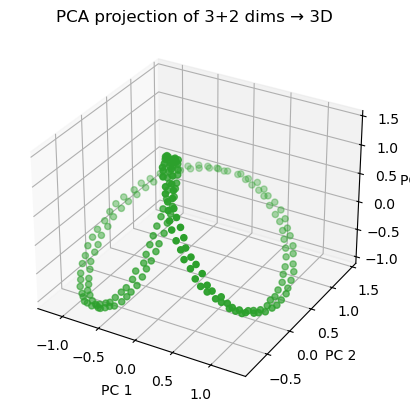

In [13]:
# Example usage:
X, Y = gen_exploration_dataset(200, 3, 2, seed=42, noise=0.01)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

plot_dataset(X, Y)

Again, our implementation is not very efficient, but we can confirm that it works as expected!

In [14]:
coeffs, approx, f_approx = regression(X.T, Y.T, degree=3) 

approx

Building RHS: 100%|██████████| 40/40 [00:00<00:00, 1729.04it/s]


Matrix([
[0.00704139773518081*x0**3 - 0.254024343636938*x0**2*x1 - 0.0899657159604074*x0**2*x2 - 1.24043052976905*x0**2 - 0.0153487088959249*x0*x1**2 + 0.473183692961416*x0*x1*x2 + 0.184658916448102*x0*x1 - 0.00108646637359364*x0*x2**2 + 0.184372800067652*x0*x2 - 0.00935758148341098*x0 + 0.113929803700006*x1**3 - 0.0890859298623051*x1**2*x2 + 0.756954052169137*x1**2 + 0.00552621348010261*x1*x2**2 + 0.0105811558721541*x1*x2 - 0.118016528624382*x1 - 0.0179842035102672*x2**3 - 0.246963204067706*x2**2 + 0.0104547528346277*x2 + 0.247133457401529],
[                     1.23406150162559*x0**3 - 0.644514625591836*x0**2*x1 + 0.954106047736825*x0**2*x2 + 0.680302875167735*x0**2 + 1.52480196251784*x0*x1**2 - 4.40164669804426*x0*x1*x2 + 2.0398531088839*x0*x1 + 0.149410966086671*x0*x2**2 + 0.854306398959082*x0*x2 - 1.38508468113273*x0 + 1.09083489808886*x1**3 + 0.794146987734553*x1**2*x2 + 0.688997298736902*x1**2 - 0.00878058969510636*x1*x2**2 - 0.306648019556132*x1*x2 - 1.08485582612941*x1 + 0.10

In [15]:
Y_pred = f_approx(X.T).squeeze()
Y_pred.shape

(2, 200)

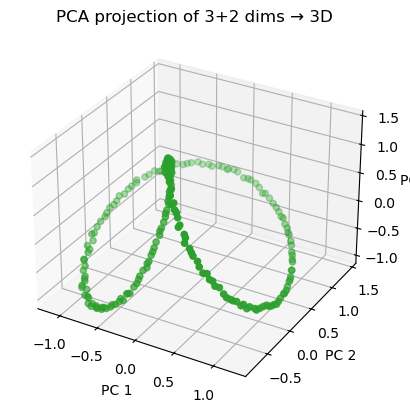

In [16]:
plot_dataset(X, Y_pred)

With lower resolution:

Building RHS: 100%|██████████| 8/8 [00:00<00:00, 1348.87it/s]


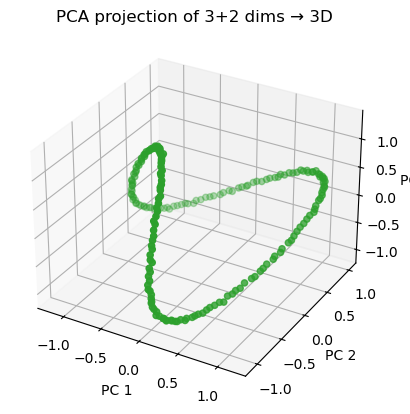

In [17]:
# Degree 1
coeffs, approx, f_approx = regression(X.T, Y.T, degree=1)
Y_pred = f_approx(X.T).squeeze()
plot_dataset(X, Y_pred)

Building RHS: 100%|██████████| 20/20 [00:00<00:00, 1621.71it/s]


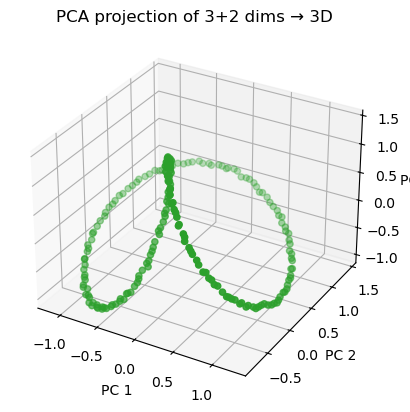

In [18]:
# Degree 2
coeffs, approx, f_approx = regression(X.T, Y.T, degree=2)
Y_pred = f_approx(X.T).squeeze()
plot_dataset(X, Y_pred)

With higher resolution, we get much closer to the original surface, although it takes significantly longer to run.

Building RHS: 100%|██████████| 572/572 [00:00<00:00, 1181.46it/s]


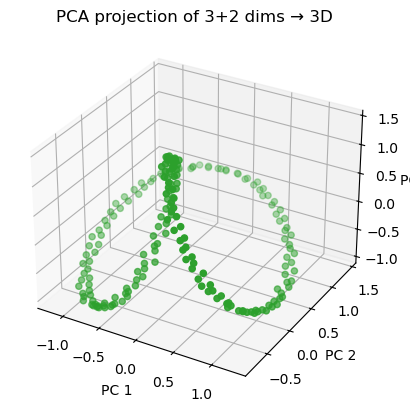

In [19]:
# Degree 10
coeffs, approx, f_approx = regression(X.T, Y.T, degree=10)
Y_pred = f_approx(X.T).squeeze()
plot_dataset(X, Y_pred)

Now, we can study the error:

Degrees: 100%|██████████| 5/5 [00:10<00:00,  2.11s/it]


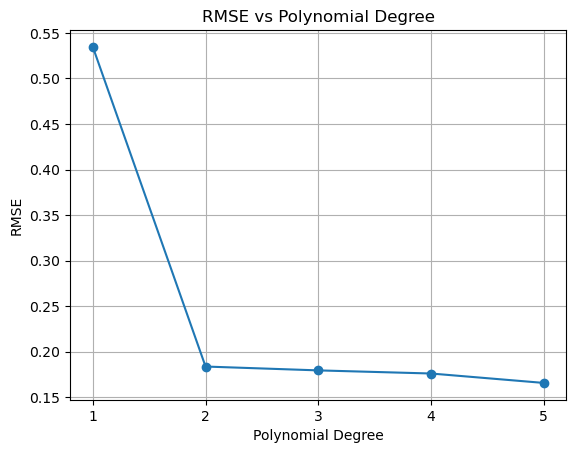

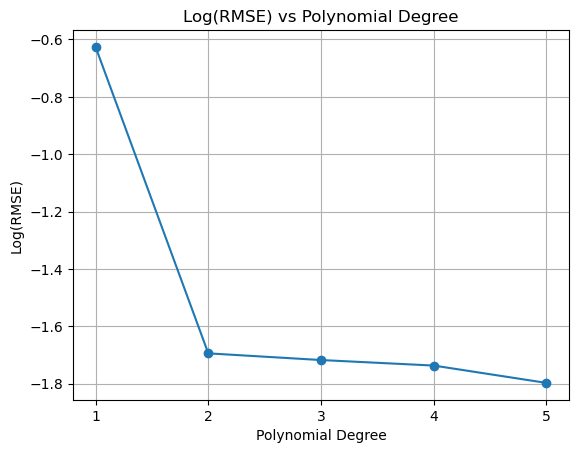

In [20]:
max_degree = 5
errors = []

for degree in tqdm(range(1, max_degree + 1), desc="Degrees"):
    # perform regression
    coeffs, approx, f_approx = regression(X.T, Y.T, degree, quiet=True)
    Y_pred = f_approx(X.T).squeeze()   # (N, m)

    # compute RMSE
    err = np.sqrt(np.mean((Y_pred - Y)**2))
    errors.append(err)

# Plot
plt.figure()
plt.plot(range(1, max_degree + 1), errors, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("RMSE vs Polynomial Degree")
plt.xticks(range(1, max_degree + 1))
plt.grid(True)
plt.show()

# Log of RSME
err_log = np.log(errors)
plt.figure()
plt.plot(range(1, max_degree + 1), err_log, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Log(RMSE)")
plt.title("Log(RMSE) vs Polynomial Degree")
plt.xticks(range(1, max_degree + 1))
plt.grid(True)
plt.show()

## Target Problem
---

Now, let's work with our target problem. Below is the MATLAB code we started from, annotated with comments for clarity:


> ```matlab
> % Clear workspace and command window
> clear; clc;
>
> % Define time vector t from 0 to 2.6 in steps of 0.2
> t = 0:.2:2.6; 
> % Define parameter vector q from 1 to 2 in steps of 0.2
> q = 1:.2:2;
>
> for k = 1:numel(t)
>     for ell = 1:numel(q)
>         %------------------------------------------------------------------
>         % Define basis “phi” column-vectors (length 4) for each term
>         %------------------------------------------------------------------
>         phi0 = [1 0 0 0]';   % constant
>         phi1 = [0 1 0 0]';
>         phi2 = [0 0 1 0]';
>         phi3 = [0 0 0 1]';
>         
>         phi4 = [t(k)   0    0 0]';  % linear in t
>         phi5 = [  0  t(k)   0 0]';
>         
>         phi6 = [0 0 q(ell) 0]';     % linear in q
>         phi7 = [0 0    0  q(ell)]';
>         
>         phi8 = [t(k)^2 0 0 0]';     % quadratic in t
>         phi9 = [0      0 0 sin(t(k))]'; % sinusoidal in t
>         
>         %------------------------------------------------------------------
>         % Build X: sum of constant + linear terms
>         %------------------------------------------------------------------
>         x(:, k+ell-1) = phi0 + phi1 + phi2 + phi3 ...
>                       + phi4 + phi5 + phi6 + phi7;
>         
>         %------------------------------------------------------------------
>         % Build Y: weighted combo + small quadratic & sinusoidal terms
>         %------------------------------------------------------------------
>         y(:, k+ell-1) = 2*phi0 + phi1 - phi2 + 4*phi3 ...
>                       + 5*phi4 + 2*phi5 - phi6 + phi7 ...
>                       + 0.1*phi8 + 0.2*phi9;
>     end
> end
> ```

We've rewritten it in Python.

In [21]:
def create_dataset():
    # Define parameter grids
    t = np.arange(0, 2.6 + 0.2, 0.2)
    q = np.arange(1,   2.0 + 0.2, 0.2)
    
    Nt, Nq = t.size, q.size
    N = Nt + Nq - 1
    
    # Pre‐allocate output
    X = np.zeros((4, N))
    Y = np.zeros((4, N))
    
    # Build up each column exactly as before
    for k in range(Nt):
        for ell in range(Nq):
            # Basis “phi” vectors
            phi0 = np.array([1, 0, 0, 0])
            phi1 = np.array([0, 1, 0, 0])
            phi2 = np.array([0, 0, 1, 0])
            phi3 = np.array([0, 0, 0, 1])
            phi4 = np.array([t[k], 0, 0, 0])
            phi5 = np.array([0, t[k], 0, 0])
            phi6 = np.array([0, 0, q[ell], 0])
            phi7 = np.array([0, 0, 0, q[ell]])
            phi8 = np.array([t[k]**2, 0, 0, 0])
            phi9 = np.array([0, 0, 0, np.sin(t[k])])
            
            idx = k + ell  # 0-based combined index
            
            X[:, idx] = (
                phi0 + phi1 + phi2 + phi3
                + phi4 + phi5 + phi6 + phi7
            )
            Y[:, idx] = (
                2*phi0 + phi1 - phi2 + 4*phi3
                + 5*phi4 + 2*phi5 - phi6 + phi7
                + 0.1*phi8 + 0.2*phi9
            )
    
    return X, Y

We can represent the terms we will be using like this:

In [22]:
I = sp.eye(4)
e1, e2, e3, e4 = [sp.ImmutableMatrix(I[:, i]) for i in range(4)]
x1, x2, x3, x4 = sp.symbols('x1 x2 x3 x4')

terms = [
    e1, e2, e3, e4,
    x1 * e1, x2 * e2, x3 * e3, x4 * e4
]

display(sp.MatAdd(*terms, evaluate=False))


Matrix([
[0],
[0],
[0],
[1]]) + Matrix([
[ 0],
[ 0],
[ 0],
[x4]]) + Matrix([
[0],
[0],
[1],
[0]]) + Matrix([
[ 0],
[ 0],
[x3],
[ 0]]) + Matrix([
[0],
[1],
[0],
[0]]) + Matrix([
[ 0],
[x2],
[ 0],
[ 0]]) + Matrix([
[1],
[0],
[0],
[0]]) + Matrix([
[x1],
[ 0],
[ 0],
[ 0]])

Now, let's instantiate the dataset and see how it looks.

X shape: (4, 20)
Y shape: (4, 20)


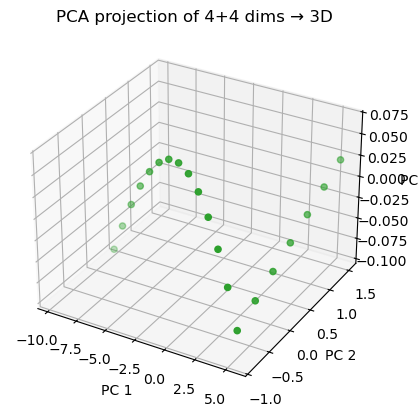

In [23]:
X, Y = create_dataset()
print("X shape:", X.shape)
print("Y shape:", Y.shape)

plot_dataset(X, Y)

Now, let's do the regression. Since the specification only asked for degree 1, this will be fast.

Building RHS: 100%|██████████| 20/20 [00:00<00:00, 9707.91it/s]


Coefficients:


Matrix([
[    -3.57288135593309],
[     -1.0000000000002],
[ 4.70734562441066e-14],
[     3.21533170613637],
[   0.0462711864409085],
[ 7.16303514257173e-14],
[   -0.499999999999968],
[    0.460069814590803],
[     2.63661016949153],
[     1.00000000000004],
[-1.06282256214436e-15],
[   0.0162085598945429],
[      2.6366101694915],
[    0.999999999999955],
[-1.17384486460688e-15],
[   0.0162085598945424],
[   0.0462711864409425],
[ 4.49849988347135e-14],
[   -0.500000000000051],
[    0.460069814590769]])

Approximation:


Matrix([
[            2.63661016949153*x0 + 2.6366101694915*x1 + 0.0462711864409425*x2 + 0.0462711864409085*x3 - 3.57288135593309],
[       1.00000000000004*x0 + 0.999999999999955*x1 + 4.49849988347135e-14*x2 + 7.16303514257173e-14*x3 - 1.0000000000002],
[-1.06282256214436e-15*x0 - 1.17384486460688e-15*x1 - 0.500000000000051*x2 - 0.499999999999968*x3 + 4.70734562441066e-14],
[         0.0162085598945429*x0 + 0.0162085598945424*x1 + 0.460069814590769*x2 + 0.460069814590803*x3 + 3.21533170613637]])

Plot


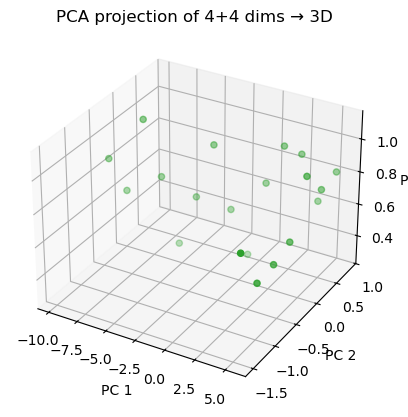

In [24]:
coeffs, approx, f_approx = regression(X.T, Y.T, degree=1)

print('\n' + '='*40)
print("Coefficients:")
display(coeffs)

print("Approximation:")
display(approx)

print("Plot")
Y_pred = f_approx(X.T).squeeze()
plot_dataset(X, Y_pred)

Now, for fun, let's see what a higher-degree approximation can do.

Building RHS: 100%|██████████| 140/140 [00:00<00:00, 12755.01it/s]


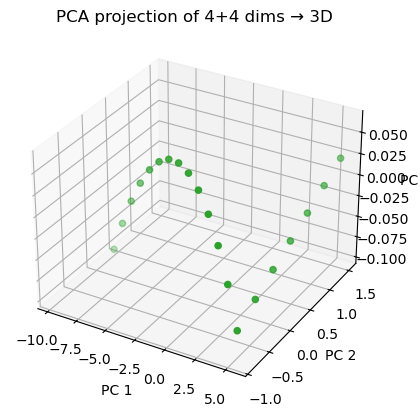

In [25]:
# Degree 3
coeffs, approx, f_approx = regression(X.T, Y.T, degree=3)
Y_pred = f_approx(X.T).squeeze()
plot_dataset(X, Y_pred)

Building RHS: 100%|██████████| 504/504 [00:00<00:00, 9010.82it/s]


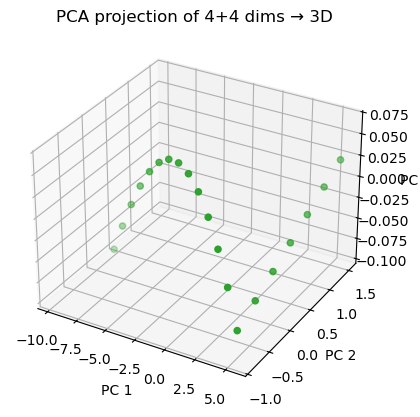

In [26]:
# Degree 5
coeffs, approx, f_approx = regression(X.T, Y.T, degree=5)
Y_pred = f_approx(X.T).squeeze()
plot_dataset(X, Y_pred)